# **Setup & Load Gold Layer Tables**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.options.display.float_format = '{:,.2f}'.format

GOLD_FILE = 'gold_layer_amazon_sales (3).xlsx'

dim_date = pd.read_excel(GOLD_FILE, sheet_name='Dim_Date')
dim_product = pd.read_excel(GOLD_FILE, sheet_name='Dim_Product')
dim_account_market = pd.read_excel(GOLD_FILE, sheet_name='Dim_Account_Market')
fact_sales = pd.read_excel(GOLD_FILE, sheet_name='Fact_Sales')

dim_date['Date'] = pd.to_datetime(dim_date['Date'])

print('Fact_Sales:', fact_sales.shape)
print('Dim_Date:', dim_date.shape)
print('Dim_Product:', dim_product.shape)
print('Dim_Account_Market:', dim_account_market.shape)

Fact_Sales: (13323, 28)
Dim_Date: (209, 10)
Dim_Product: (102, 8)
Dim_Account_Market: (5, 3)


In [6]:
# Build one denormalized analysis table (Fact + all Dims joined)
# This is the equivalent of the "Model View" relationships we will build in Power BI

df = (
    fact_sales
    .merge(dim_date, on='Date_Key', how='left')
    .merge(dim_product, on='Product_Key', how='left')
    .merge(dim_account_market, on='Account_Market_Key', how='left')
)

print('Joined analysis table shape:', df.shape)
df.head(3)

Joined analysis table shape: (13323, 46)


,Date_Key,Product_Key,Account_Market_Key,Taxes,Orders,Units,Refunded,Refund %,Unit Session %,Promo Units,...,Is_Weekend,SKU,FNSKU,ASIN,Parent ASIN,Is Parent,Brand,Title,Market Place,Account Title
0,1,1,1,-50.34,17,17,0,0.00,0.00,0,...,False,UK_Aava_Magnesium_400mg_120_05,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava
1,2,1,1,-58.89,20,20,0,0.00,0.00,0,...,False,UK_Aava_Magnesium_400mg_120_05,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava
2,3,1,1,-72.41,18,24,0,0.00,0.00,0,...,True,UK_Aava_Magnesium_400mg_120_05,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...,UK,[ UK ] Aava


# **PAGE 6 — Promotions & Returns Analysis**
*(Power BI Page 6: "Promotions & Returns")*

**KPIs on this page:**
- Total Promo Units
- Total Promo Amount ($)
- Total Refunded Units
- Average Refund %

**Business Questions:**
1. What share of units sold come from Promotions vs Organic? → **Donut Chart**
2. How has Promo spend trended month over month? → **Line Chart**
3. What are the Top 10 products by Promo Units? → **Horizontal Bar Chart**
4. Is there a relationship between Promo Amount and Refund %? → **Scatter Plot**


In [7]:
# --- KPI Cards ---
total_promo_units = df['Promo Units'].sum()
total_promo_amount = df['Promo Amount'].sum()
total_refunded_units = df['Refunded'].sum()
avg_refund_pct = df['Refund %'].mean()

print(f"Total Promo Units:      {total_promo_units:,.0f}")
print(f"Total Promo Amount:     ${total_promo_amount:,.2f}")
print(f"Total Refunded Units:    {total_refunded_units:,.0f}")
print(f"Average Refund %:        {avg_refund_pct:.2%}")

Total Promo Units:      193
Total Promo Amount:     $-156,765.64
Total Refunded Units:    3,446
Average Refund %:        1.71%


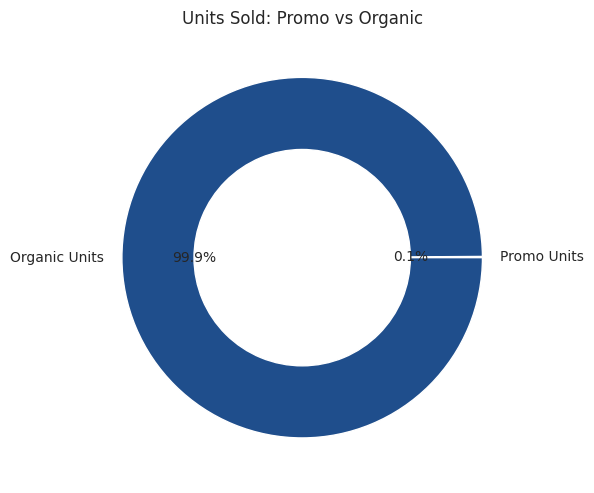

In [8]:
# Q1: Promo vs Organic Units Share -> Donut Chart
units_split = pd.DataFrame({
    'Type': ['Promo Units', 'Organic Units'],
    'Units': [df['Promo Units'].sum(), df['Organic Units'].sum()]
})

plt.figure(figsize=(6, 6))
plt.pie(units_split['Units'], labels=units_split['Type'], autopct='%1.1f%%',
        colors=['#e07b39', '#1f4e8c'], wedgeprops={'width': 0.4})
plt.title('Units Sold: Promo vs Organic')
plt.tight_layout()
plt.show()

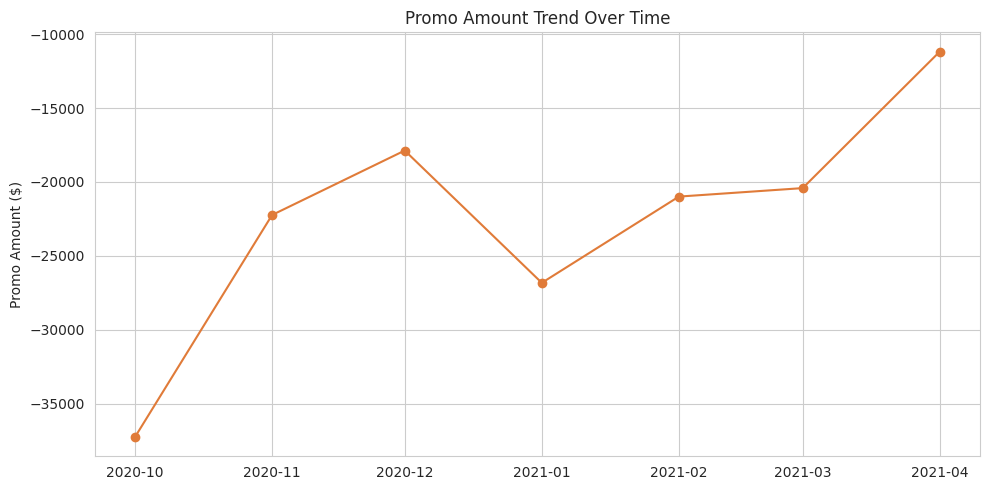

In [9]:
# Q2: Promo Spend Trend Over Time -> Line Chart
promo_trend = df.groupby(['Year', 'Month'], as_index=False).agg(Promo_Amount=('Promo Amount', 'sum'))
promo_trend['Period'] = pd.to_datetime(promo_trend[['Year', 'Month']].assign(DAY=1))
promo_trend = promo_trend.sort_values('Period')

plt.figure()
plt.plot(promo_trend['Period'], promo_trend['Promo_Amount'], marker='o', color='#e07b39')
plt.title('Promo Amount Trend Over Time')
plt.ylabel('Promo Amount ($)')
plt.tight_layout()
plt.show()

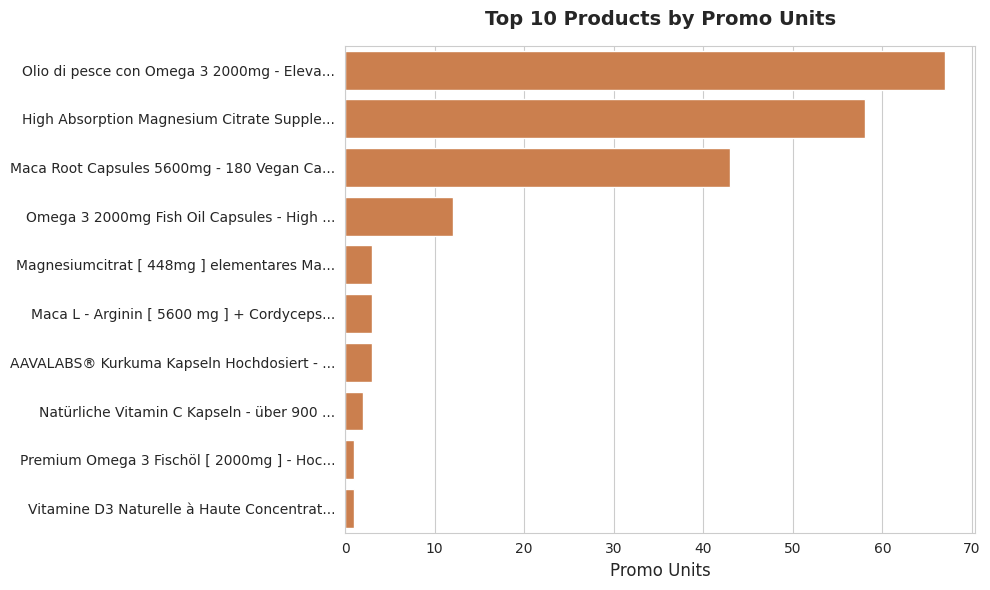

In [12]:
# Q3: Top 10 Products by Promo Units -> Horizontal Bar Chart
top10_promo = df.groupby('Title', as_index=False).agg(Promo_Units=('Promo Units', 'sum')).sort_values('Promo_Units', ascending=False).head(10)
top10_promo['Short_Title'] = top10_promo['Title'].apply(lambda x: x[:40] + '...' if len(str(x)) > 40 else x)
plt.figure(figsize=(10, 6))
sns.barplot(data=top10_promo, y='Short_Title', x='Promo_Units', color='#e07b39')
plt.title('Top 10 Products by Promo Units', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Promo Units', fontsize=12)
plt.ylabel('')

plt.tight_layout()
plt.show()

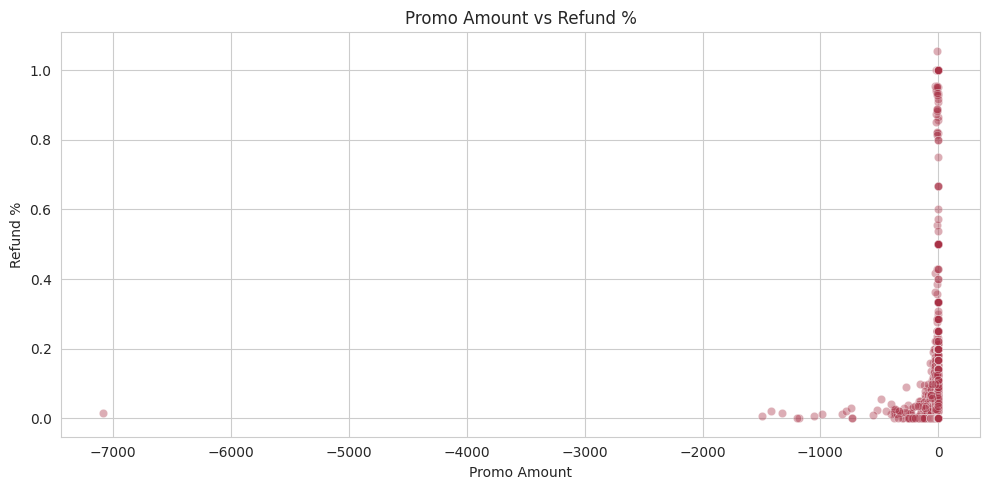

In [11]:
# Q4: Promo Amount vs Refund % -> Scatter Plot
plt.figure()
sns.scatterplot(data=df, x='Promo Amount', y='Refund %', alpha=0.4, color='#a83246')
plt.title('Promo Amount vs Refund %')
plt.tight_layout()
plt.show()